In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..") / "src"))

In [2]:
from run_fit import run
from io_utils import load_fit3_inputs
from params_utils import read_params_csv, update_pack_values
from fit3 import load_config, estimate_edge_coefficients
from spectral_reconstruction import (
    reconstruct_state_spectra,
    compute_populations,
    reconstruct_all_spectra,
    reconstruct_spectrum_at_index,
)

In [3]:
n_components = 3

x_final, summary = run("../configs/fit3_config.json", n_components=n_components)

summary

{'run_timestamp': '2026-03-31_14-27-43',
 'config_path': '../configs/fit3_config.json',
 'n_components': 3,
 'stage1_success': True,
 'stage1_cost': 0.02724764871126705,
 'stage2_success': True,
 'stage2_cost': 0.02480873441876697,
 'T_shape': [41],
 'V_prime_shape': [3, 41],
 'U_prime_shape': [221, 3],
 'spectral_matrix_shape': [221, 41],
 'wavelengths_shape': [221],
 'preprocess_coeffs': {'C11': 0.17914457270243378,
  'C21': -0.06334541521769797,
  'C31': 0.3344922692393428,
  'C13': 0.012580350421504778,
  'C23': 0.4042360826666315,
  'C33': 0.17439882620973818},
 'output_dir': '../results/fit3_run/fit3_2026-03-31_14-27-43',
 'final_params': {'Tm1': 324.2133822380313,
  'Tm2': 359.1830528914419,
  'dH1': -13052.26845378919,
  'dH2': -58145.860497129834,
  'C11': 0.1807800854132836,
  'C12': 0.17361535147139187,
  'C13': 0.003099600079883927,
  'C21': -0.06670430352736927,
  'C22': 0.01139134215245286,
  'C23': 0.43042615025951175,
  'C31': 0.3416893334593017,
  'C32': -0.38325001037

In [4]:
import numpy as np

cfg = load_config("../configs/fit3_config.json")

pack = read_params_csv(cfg["params_csv"])

T, V_prime, U_prime, spectral_matrix, wavelengths = load_fit3_inputs(
    cfg["data"]["spectra_matrix_path"],
    cfg["data"]["V_prime_path"],
    cfg["data"]["U_prime_path"],
)

preprocess_coeffs, _ = estimate_edge_coefficients(U_prime, spectral_matrix)
pack = update_pack_values(pack, preprocess_coeffs)

T = T + 273.15  # Kelvin

state_spectra = reconstruct_state_spectra(U_prime, x_final, pack)
M = compute_populations(T, x_final, pack)
recon = reconstruct_all_spectra(T, U_prime, x_final, pack)

spectra_pred = recon["spectra_pred"]

print("T shape:", T.shape)
print("U_prime shape:", U_prime.shape)
print("M shape:", M.shape)
print("spectra_pred shape:", spectra_pred.shape)

T shape: (41,)
U_prime shape: (221, 3)
M shape: (3, 41)
spectra_pred shape: (221, 41)


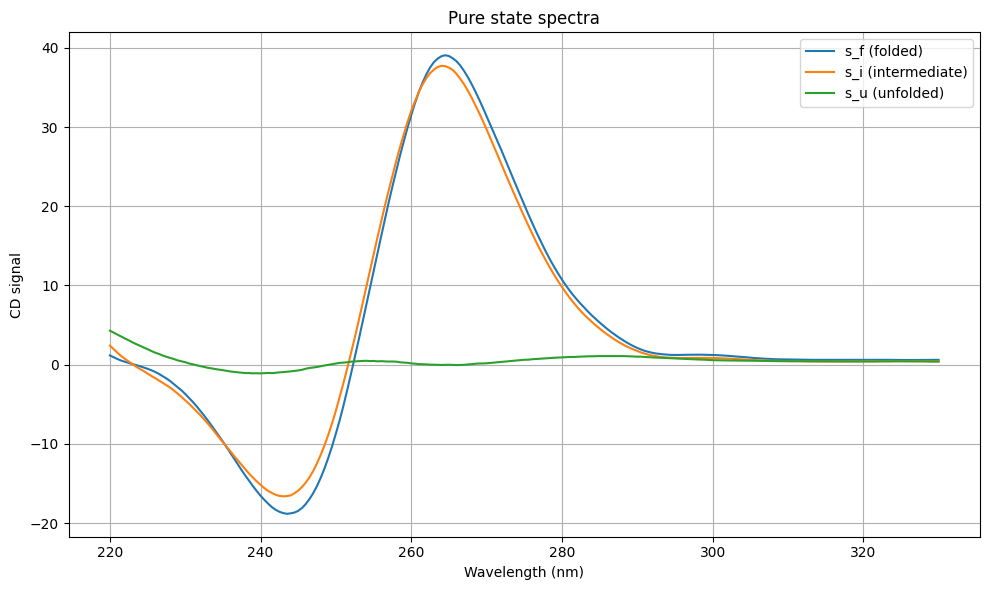

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(wavelengths, state_spectra["s_f"], label="s_f (folded)")
plt.plot(wavelengths, state_spectra["s_i"], label="s_i (intermediate)")
plt.plot(wavelengths, state_spectra["s_u"], label="s_u (unfolded)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("CD signal")
plt.title("Pure state spectra")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

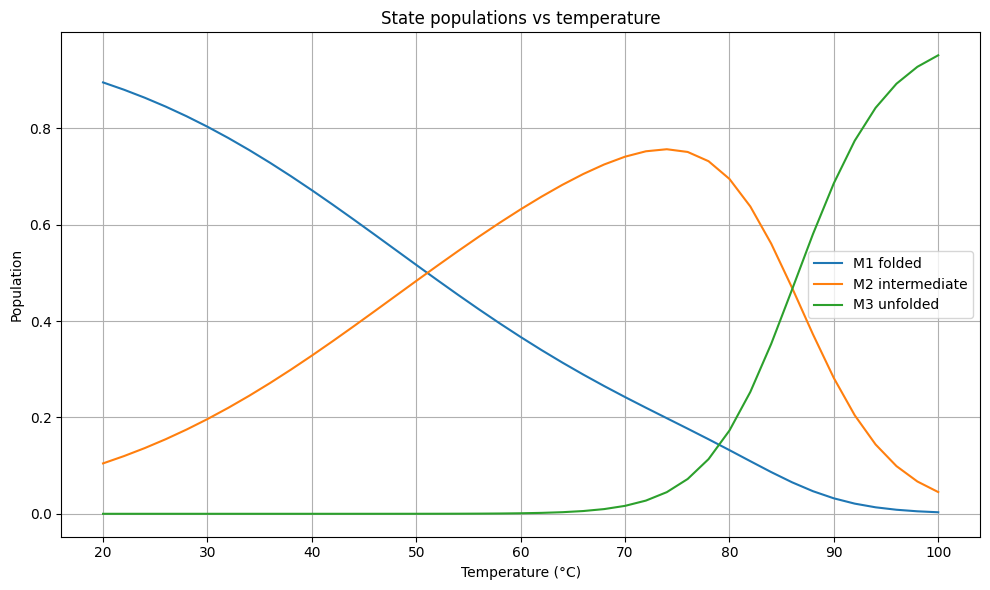

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(T - 273.15, M[0], label="M1 folded")
plt.plot(T - 273.15, M[1], label="M2 intermediate")
plt.plot(T - 273.15, M[2], label="M3 unfolded")
plt.xlabel("Temperature (°C)")
plt.ylabel("Population")
plt.title("State populations vs temperature")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
import ipywidgets as widgets
from IPython.display import display

def plot_reconstructed_spectrum(idx):
    result = reconstruct_spectrum_at_index(T, U_prime, x_final, pack, idx)

    spectrum = result["spectrum"]
    T_celsius = result["T_kelvin"] - 273.15
    M_vec = result["M"]

    plt.figure(figsize=(10, 6))
    plt.plot(wavelengths, spectrum, label=f"Reconstructed spectrum at {T_celsius:.1f} °C")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("CD signal")
    plt.title(
        f"Reconstructed spectrum | "
        f"M1={M_vec[0]:.3f}, M2={M_vec[1]:.3f}, M3={M_vec[2]:.3f}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(T) - 1,
    step=1,
    description="T index"
)

interactive_plot = widgets.interactive_output(
    plot_reconstructed_spectrum,
    {"idx": slider}
)

display(slider, interactive_plot)

IntSlider(value=0, description='T index', max=40)

Output()